# Прогнозирование одного временного ряда: BTC-USD


Данные берем из `yfinance`: дневные цены `BTC-USD`.

Цель: прогнозировать будущие значения `Close` на несколько дней вперед.

## План занятия

Задача:

$$
\hat{y}_{t+1:t+H} = f(y_{t-C+1:t}),
$$

где:

- $C$ — длина исторического контекста;
- $H$ — горизонт прогноза;
- $y_t$ — цена закрытия в момент времени $t$.

## Принцип без look-ahead bias

Во временных рядах нельзя перемешивать наблюдения случайно, если мы имитируем реальный прогноз.

Правильная структура:

$$
\text{train} \rightarrow \text{validation} \rightarrow \text{test}.
$$

Запрещено:

- обучать scaler на всей истории;
- выбирать гиперпараметры по test;
- использовать будущие значения в признаках;
- случайно перемешивать временные окна между train/test;
- строить признаки, которые смотрят вперед.

В этом блокноте:

- данные сортируются по дате;
- scaler обучается только на train;
- validation и test идут позже train;
- каждое окно использует только прошлый контекст для прогноза будущего горизонта.

## 1. Установка библиотек

In [1]:
import os
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 100

I0000 00:00:1781083446.960960   14966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781083447.333389   14966 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781083448.528343   14966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Загрузка BTC-USD через yfinance

Берем только `Close`. 

В реальной задаче можно использовать:

- `Open`, `High`, `Low`, `Close`;
- `Volume`;
- календарные признаки;
- данные других активов;
- макроэкономические признаки.

In [10]:
TICKER = "BTC-USD"
START_DATE = "2018-01-01"

raw = yf.download(TICKER, start=START_DATE, auto_adjust=True, progress=False)
raw = raw.dropna().sort_index()

series = raw[["Close"]].copy()
series.columns = ["close"]

print(series.head())
print(series.tail())
print(series.shape)

                   close
Date                    
2018-01-01  13657.200195
2018-01-02  14982.099609
2018-01-03  15201.000000
2018-01-04  15599.200195
2018-01-05  17429.500000
                   close
Date                    
2026-06-06  60867.414062
2026-06-07  63239.519531
2026-06-08  63090.589844
2026-06-09  61643.781250
2026-06-10  60913.058594
(3083, 1)


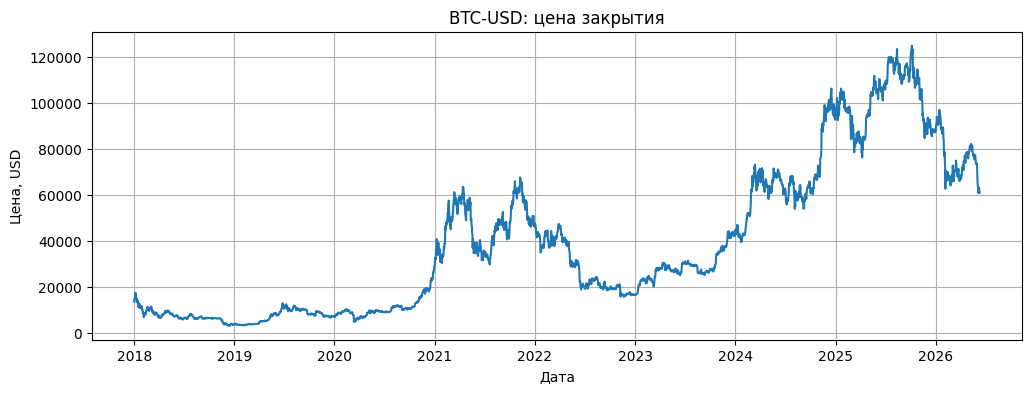

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(series.index, series["close"])
plt.title("BTC-USD: цена закрытия")
plt.xlabel("Дата")
plt.ylabel("Цена, USD")
plt.grid(True)
plt.show()

## 3. Temporal split

Делим ряд по времени:

- 70% train;
- 15% validation;
- 15% test.

Validation используется для ранней остановки и выбора модели.
Test используется только для финального сравнения.

In [12]:
def temporal_split(frame, train_size=0.70, val_size=0.15):
    """
    Делит DataFrame на train, validation и test по времени.

    Аргументы:
        frame: DataFrame, отсортированный по дате.
        train_size: доля train.
        val_size: доля validation.

    Возвращает:
        train, validation, test.
    """
    n = len(frame)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))

    train = frame.iloc[:train_end].copy()
    validation = frame.iloc[train_end:val_end].copy()
    test = frame.iloc[val_end:].copy()

    return train, validation, test


train_df, val_df, test_df = temporal_split(series)

print(train_df.index.min(), train_df.index.max(), train_df.shape)
print(val_df.index.min(), val_df.index.max(), val_df.shape)
print(test_df.index.min(), test_df.index.max(), test_df.shape)

2018-01-01 00:00:00 2023-11-28 00:00:00 (2158, 1)
2023-11-29 00:00:00 2025-03-04 00:00:00 (462, 1)
2025-03-05 00:00:00 2026-06-10 00:00:00 (463, 1)


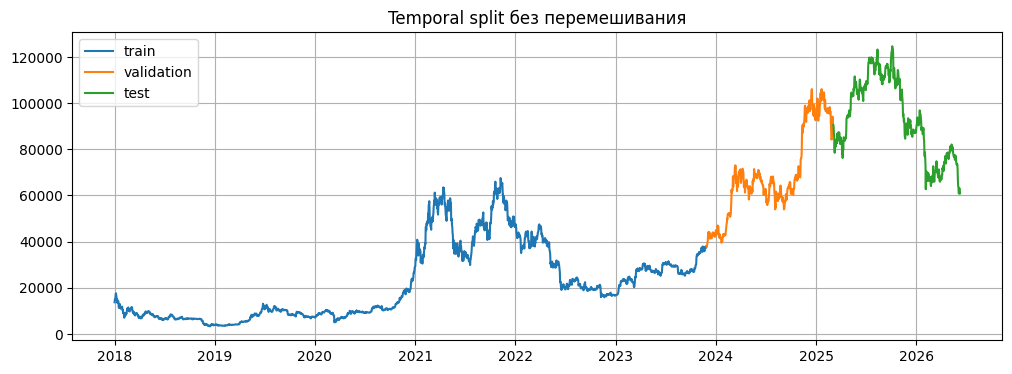

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(train_df.index, train_df["close"], label="train")
plt.plot(val_df.index, val_df["close"], label="validation")
plt.plot(test_df.index, test_df["close"], label="test")
plt.title("Temporal split без перемешивания")
plt.legend()
plt.grid(True)
plt.show()

## 4. Масштабирование без утечки будущего

Scaler обучается только на `train`.

Потом тот же scaler применяется к `validation` и `test`.

Это важно: если обучить scaler на всем ряде, статистики будущего попадут в train pipeline.

In [14]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["close"]])
val_scaled = scaler.transform(val_df[["close"]])
test_scaled = scaler.transform(test_df[["close"]])

scaled_full = np.concatenate([train_scaled, val_scaled, test_scaled], axis=0)

train_end = len(train_scaled)
val_end = len(train_scaled) + len(val_scaled)

print(scaled_full.shape)

(3083, 1)


## 5. Sliding windows

Каждый пример:

- вход: последние `CONTEXT_LENGTH` значений;
- target: следующие `PREDICTION_LENGTH` значений.

Для test окон начало контекста может попадать в validation, потому что в реальном прогнозе у нас есть вся история до момента прогноза. Но target test-окон находится только в test-периоде.

In [15]:
CONTEXT_LENGTH = 90
PREDICTION_LENGTH = 14
BATCH_SIZE = 32
EPOCHS = 20


def make_supervised_windows(values, context_length, prediction_length, start_target, end_target):
    """
    Создает supervised окна для direct multi-step forecasting.

    Аргументы:
        values: массив формы (T, 1), уже масштабированный.
        context_length: длина исторического контекста.
        prediction_length: горизонт прогноза.
        start_target: минимальный индекс первого target значения.
        end_target: максимальная граница target периода.

    Возвращает:
        X: массив формы (N, context_length, 1).
        y: массив формы (N, prediction_length).
        target_indices: список индексов первого target значения.
    """
    X, y, target_indices = [], [], []

    for target_start in range(start_target, end_target - prediction_length + 1):
        context_start = target_start - context_length
        context_end = target_start

        if context_start < 0:
            continue

        X.append(values[context_start:context_end])
        y.append(values[target_start:target_start + prediction_length, 0])
        target_indices.append(target_start)

    return np.asarray(X, dtype="float32"), np.asarray(y, dtype="float32"), np.asarray(target_indices)


X_train, y_train, idx_train = make_supervised_windows(
    scaled_full,
    CONTEXT_LENGTH,
    PREDICTION_LENGTH,
    start_target=CONTEXT_LENGTH,
    end_target=train_end,
)

X_val, y_val, idx_val = make_supervised_windows(
    scaled_full,
    CONTEXT_LENGTH,
    PREDICTION_LENGTH,
    start_target=train_end,
    end_target=val_end,
)

X_test, y_test, idx_test = make_supervised_windows(
    scaled_full,
    CONTEXT_LENGTH,
    PREDICTION_LENGTH,
    start_target=val_end,
    end_target=len(scaled_full),
)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2055, 90, 1) (2055, 14)
(449, 90, 1) (449, 14)
(450, 90, 1) (450, 14)


In [16]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

W0000 00:00:1781083515.187337   14966 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1781083515.190317   14966 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781083515.375945   14966 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


## 6. Метрики и обратное масштабирование

Оцениваем прогноз в исходных долларах.

Метрики:

$$
MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|,
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}.
$$

In [17]:
def inverse_close(values):
    """
    Возвращает значения close из стандартизированного масштаба в USD.

    Аргументы:
        values: массив любой формы.

    Возвращает:
        Массив той же формы в исходном масштабе.
    """
    original_shape = values.shape
    flat = values.reshape(-1, 1)
    inverted = scaler.inverse_transform(flat).reshape(original_shape)
    return inverted


def evaluate_forecast(y_true_scaled, y_pred_scaled, model_name):
    """
    Считает MAE и RMSE в исходном масштабе.

    Аргументы:
        y_true_scaled: истинные значения в стандартизированном масштабе.
        y_pred_scaled: прогноз в стандартизированном масштабе.
        model_name: название модели.

    Возвращает:
        Словарь с метриками.
    """
    y_true = inverse_close(y_true_scaled)
    y_pred = inverse_close(y_pred_scaled)

    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))

    return {"model": model_name, "MAE_USD": mae, "RMSE_USD": rmse}


def plot_one_forecast(y_true_scaled, y_pred_scaled, title, sample_id=0):
    """
    Рисует один пример прогноза.

    Аргументы:
        y_true_scaled: истинные значения.
        y_pred_scaled: прогноз.
        title: заголовок графика.
        sample_id: номер тестового окна.
    """
    true_values = inverse_close(y_true_scaled[sample_id])
    pred_values = inverse_close(y_pred_scaled[sample_id])

    plt.figure(figsize=(8, 4))
    plt.plot(true_values, marker="o", label="true")
    plt.plot(pred_values, marker="o", label="forecast")
    plt.title(title)
    plt.xlabel("Шаг прогноза")
    plt.ylabel("Close, USD")
    plt.legend()
    plt.grid(True)
    plt.show()

# TensorFlow модели

Все TensorFlow-модели делают direct multi-step forecast:

$$
(C, 1) \rightarrow (H).
$$

Это проще и честнее для демонстрации, чем рекурсивно подставлять собственные прогнозы.

In [18]:
def make_tf_callbacks():
    """
    Создает callbacks для TensorFlow моделей.
    """
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1),
    ]


def build_lstm_model():
    """
    Строит LSTM модель для univariate forecasting.
    """
    inputs = keras.Input(shape=(CONTEXT_LENGTH, 1))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(PREDICTION_LENGTH)(x)
    model = keras.Model(inputs, outputs, name="lstm_forecaster")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


def build_gru_model():
    """
    Строит GRU модель для univariate forecasting.
    """
    inputs = keras.Input(shape=(CONTEXT_LENGTH, 1))
    x = layers.GRU(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.GRU(32)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(PREDICTION_LENGTH)(x)
    model = keras.Model(inputs, outputs, name="gru_forecaster")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


def transformer_encoder_block(x, num_heads=4, key_dim=16, ff_dim=128, dropout=0.2):
    """
    Один encoder-блок Transformer.
    """
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout)(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    ffn = layers.Dense(ff_dim, activation="gelu")(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(x.shape[-1])(ffn)
    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x


def build_tf_transformer_model():
    """
    Строит простой Transformer Encoder для univariate forecasting.
    """
    inputs = keras.Input(shape=(CONTEXT_LENGTH, 1))
    x = layers.Dense(64)(inputs)  # shape: (batch, CONTEXT_LENGTH, 64)
    
    positions = tf.range(start=0, limit=CONTEXT_LENGTH, delta=1)  # (CONTEXT_LENGTH,)
    pos_emb = layers.Embedding(input_dim=CONTEXT_LENGTH, output_dim=64)(positions)  # (CONTEXT_LENGTH, 64)
    pos_emb = tf.expand_dims(pos_emb, axis=0)  # (1, CONTEXT_LENGTH, 64)
    
    # x имеет форму (batch, CONTEXT_LENGTH, 64)
    # pos_emb имеет форму (1, CONTEXT_LENGTH, 64)
    # TensorFlow автоматически транслирует pos_emb на все batch
    x = layers.Add()([x, pos_emb])
    
    x = transformer_encoder_block(x)
    x = transformer_encoder_block(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="gelu")(x)
    outputs = layers.Dense(PREDICTION_LENGTH)(x)
    model = keras.Model(inputs, outputs, name="tf_transformer_forecaster")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

In [19]:
tf_results = []
tf_predictions = {}

for name, builder in [
    ("LSTM", build_lstm_model),
    ("GRU", build_gru_model),
    ("TensorFlow Transformer", build_tf_transformer_model),
]:
    print("\n", "=" * 80)
    tf.keras.backend.clear_session()
    print(name)
    model = builder()
    model.summary()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=make_tf_callbacks(), verbose=1)
    pred = model.predict(X_test, verbose=0)
    tf_predictions[name] = pred
    tf_results.append(evaluate_forecast(y_test, pred, name))

pd.DataFrame(tf_results)


LSTM


Model: "lstm_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 90, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 90, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,334 (126.30 KB)

 Trainable params: 32,334 (126.30 KB)

...

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.5140

I0000 00:00:1781083567.773434   15126 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22335__.16
I0000 00:00:1781083569.344032   15121 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22335__.17


65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 166ms/step - loss: 0.2933 - val_loss: 2.7989 - learning_rate: 0.0010
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1479 - val_loss: 3.2383 - learning_rate: 0.0010
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1117 - val_loss: 2.1430 - learning_rate: 0.0010
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0492 - val_loss: 4.9706 - learning_rate: 0.0010
Epoch 5/20
51/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1541
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1247 - val_loss: 3.4188 - learning_rate: 0.0010
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0513 - val_loss: 2.2470 - learning_rate: 5.0000e-04
Epoch 7/20
49/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0346
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0336 - val_loss: 2.2958 - learning_r

I0000 00:00:1781083572.130024   15122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24652__.14
I0000 00:00:1781083573.148224   15125 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25040__.14


,model,MAE_USD,RMSE_USD
0,LSTM,21582.392578,25569.251534
1,GRU,20272.060547,24440.666439
2,TensorFlow Transformer,39568.164062,43005.998465


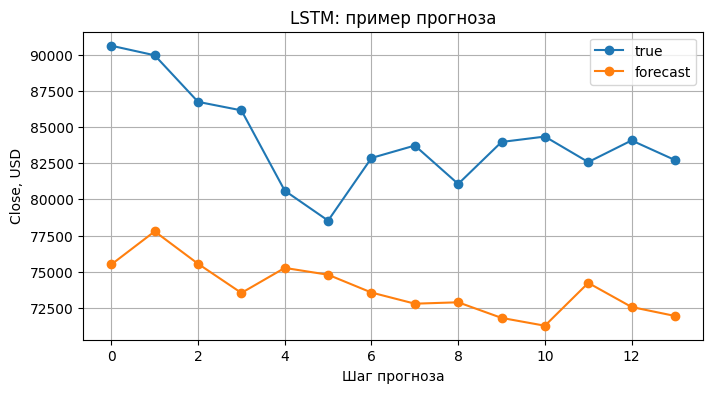

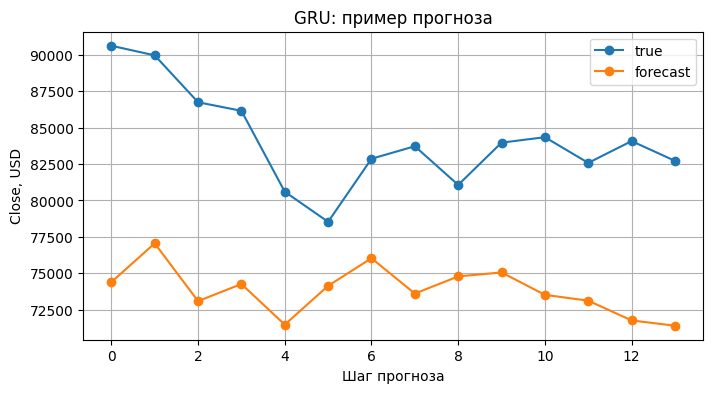

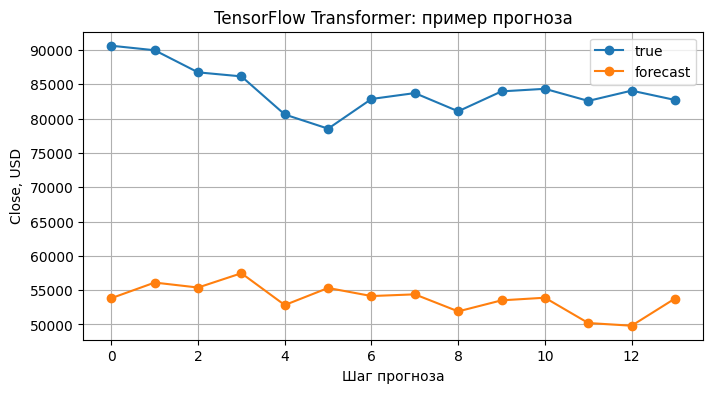

In [20]:
plot_one_forecast(y_test, tf_predictions["LSTM"], "LSTM: пример прогноза")
plot_one_forecast(y_test, tf_predictions["GRU"], "GRU: пример прогноза")
plot_one_forecast(y_test, tf_predictions["TensorFlow Transformer"], "TensorFlow Transformer: пример прогноза")